# Markowitz Mean-Variance Optimization & Efficient Frontier

This notebook builds a Markowitz mean-variance portfolio from 20 US stocks across several sectors.
We download 5 years of daily prices, estimate annualized expected returns and the covariance matrix,
run a Monte Carlo simulation, solve the long-only efficient frontier with constrained optimization,
and identify the **minimum-variance** and **maximum-Sharpe** portfolios.

**Defaults:** daily data (auto-adjusted close), returns and covariance annualized by 252,
risk-free rate = 4.5%, long-only (weights sum to 1, no shorting).

## 1. Library imports

We import numpy/pandas for numerical work, yfinance for price data, and matplotlib for plotting.
We also define the project color palette (Merivale style) used throughout the charts.

In [1]:
# Core numerical and data-handling libraries
import numpy as np
import pandas as pd

# Market data download
import yfinance as yf

# Constrained optimization for the long-only efficient frontier
from scipy.optimize import minimize

# Plotting
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# --- Project style palette (Merivale style) ---
NAVY  = "#1a2744"   # primary dark tone
GOLD  = "#c5a572"   # accent for the efficient frontier
IVORY = "#f5f1e8"   # background / canvas tone

# Apply a clean, presentation-quality default style
plt.rcParams.update({
    "figure.facecolor":  IVORY,
    "axes.facecolor":    IVORY,
    "axes.edgecolor":    NAVY,
    "axes.labelcolor":   NAVY,
    "axes.titlecolor":   NAVY,
    "xtick.color":       NAVY,
    "ytick.color":       NAVY,
    "text.color":        NAVY,
    "font.size":         11,
    "axes.grid":         True,
    "grid.color":        "#d8d0c0",
    "grid.linewidth":    0.6,
})

# Reproducibility for the Monte Carlo simulation
np.random.seed(42)

# Global assumptions (from CLAUDE.md)
TRADING_DAYS = 252      # annualization factor
RISK_FREE    = 0.045    # 4.5% annual risk-free rate

print("Libraries imported and style applied.")

Libraries imported and style applied.


## 2. Download prices and compute daily returns

We define the 20-stock universe and pull 5 years of daily adjusted close prices from yfinance
(`auto_adjust=True`, so the `Close` column is already split/dividend adjusted).
We then compute simple daily percentage returns, dropping the first (NaN) row.

In [2]:
# 20-stock universe grouped by sector (see CLAUDE.md)
tickers = [
    "AAPL", "MSFT", "NVDA",          # Technology
    "PG", "KO", "WMT",              # Consumer defensive
    "AMZN", "HD",                   # Consumer cyclical
    "JNJ", "UNH", "MRK",           # Healthcare
    "JPM", "BRK-B", "V",           # Financials (BRK-B is the yfinance ticker)
    "XOM", "CVX",                  # Energy
    "CAT", "HON",                  # Industrials
    "GOOGL",                       # Communication
    "VZ",                          # Telecom
]

# Download 5 years of daily prices; auto_adjust=True gives adjusted 'Close'
raw = yf.download(tickers, period="5y", interval="1d", auto_adjust=True)

# Keep only the 'Close' column and preserve the original ticker order
prices = raw["Close"][tickers].dropna(how="all")

# Daily simple returns; drop the first NaN row
daily_returns = prices.pct_change().dropna()

print(f"Price history: {prices.shape[0]} days x {prices.shape[1]} stocks")
print(f"Date range: {prices.index.min().date()} -> {prices.index.max().date()}")
daily_returns.tail()

[                       0%                       ]

[*****                 10%                       ]  2 of 20 completed

[*******               15%                       ]  3 of 20 completed

[**********            20%                       ]  4 of 20 completed

[************          25%                       ]  5 of 20 completed

...

[**********************80%*************          ]  16 of 20 completed

[**********************95%*********************  ]  19 of 20 completed

[*********************100%***********************]  20 of 20 completed

Price history: 1255 days x 20 stocks
Date range: 2021-06-21 -> 2026-06-18


Ticker,AAPL,MSFT,NVDA,PG,KO,WMT,AMZN,HD,JNJ,UNH,MRK,JPM,BRK-B,V,XOM,CVX,CAT,HON,GOOGL,VZ
Date,,,,,,,,,,,,,,,,,,,,
2026-06-11,0.013890,-0.017667,0.022203,-0.004764,-0.012681,-0.000746,0.014748,0.022231,-0.000671,-0.004688,0.014023,0.014071,0.004362,-0.012107,-0.026690,-0.020969,0.048437,0.064309,0.003900,-0.000213
2026-06-12,-0.015222,0.001025,0.001562,0.008561,0.001091,0.004481,-0.012256,0.007300,0.010657,0.007323,-0.014160,0.023063,0.007122,0.010469,0.002797,0.007534,0.014416,0.005431,0.005339,0.024925
2026-06-15,0.018171,0.023084,0.035382,0.005681,-0.014374,-0.001818,0.031314,0.004355,-0.021630,0.011915,-0.027919,-0.004116,0.012816,0.004436,-0.041426,-0.036428,0.025654,0.032227,0.026885,-0.021617
2026-06-16,0.009513,-0.014834,-0.023723,0.013492,-0.007786,0.001738,-0.000081,0.022042,-0.002037,-0.008247,0.002350,0.036756,-0.001150,0.028720,0.006670,-0.001608,0.012346,0.009146,0.010559,-0.007223
2026-06-17,-0.010994,-0.037884,-0.013307,-0.012657,-0.004360,-0.023961,-0.034553,-0.028509,-0.004167,-0.019919,0.002344,0.007006,-0.007415,-0.008225,-0.007895,-0.014047,0.011063,-0.003835,-0.025345,-0.019046


## 3. Annualized expected returns and covariance matrix

We annualize by multiplying the mean daily return by 252 and the daily covariance matrix by 252.
These two objects (the expected-return vector and the covariance matrix) are the only inputs
the Markowitz model needs.

In [3]:
# Annualized expected returns: mean daily return x 252
mean_returns = daily_returns.mean() * TRADING_DAYS

# Annualized covariance matrix: daily covariance x 252
cov_matrix = daily_returns.cov() * TRADING_DAYS

n_assets = len(tickers)

# Quick look at the annualized expected returns (sorted, as percentages)
summary = pd.DataFrame({
    "Expected Return": mean_returns,
    "Volatility": np.sqrt(np.diag(cov_matrix)),
}).sort_values("Expected Return", ascending=False)

(summary * 100).round(2)

,Expected Return,Volatility
Ticker,,
NVDA,61.80,51.81
CAT,36.70,30.79
GOOGL,27.10,31.39
XOM,23.57,26.70
WMT,22.86,21.69
JPM,21.54,24.44
AAPL,20.48,27.53
CVX,17.66,25.11
MRK,14.17,23.72


## 4. Monte Carlo simulation (10,000 portfolios)

We generate 10,000 random long-only portfolios. For each, weights are drawn from a Dirichlet
distribution so they are non-negative and sum to 1 (no shorting). For every portfolio we record
its annualized return, volatility, and Sharpe ratio. This 'cloud' of feasible portfolios
visually traces the region bounded by the efficient frontier.

In [4]:
n_portfolios = 10_000

# Dirichlet draws give non-negative weights that sum to 1 (long-only constraint)
weights_mc = np.random.dirichlet(np.ones(n_assets), size=n_portfolios)

# Pre-extract arrays for fast vectorized math
mu = mean_returns.values            # expected returns vector
Sigma = cov_matrix.values           # covariance matrix

# Portfolio annualized returns: w . mu
mc_returns = weights_mc @ mu

# Portfolio annualized volatility: sqrt(w . Sigma . w) for each portfolio
mc_variance = np.einsum("ij,jk,ik->i", weights_mc, Sigma, weights_mc)
mc_volatility = np.sqrt(mc_variance)

# Sharpe ratio: (return - risk_free) / volatility
mc_sharpe = (mc_returns - RISK_FREE) / mc_volatility

print(f"Simulated {n_portfolios:,} long-only portfolios.")
print(f"Return range:     {mc_returns.min():.2%} -> {mc_returns.max():.2%}")
print(f"Volatility range: {mc_volatility.min():.2%} -> {mc_volatility.max():.2%}")
print(f"Max Sharpe (MC):  {mc_sharpe.max():.3f}")

Simulated 10,000 long-only portfolios.
Return range:     10.71% -> 36.66%
Volatility range: 11.98% -> 29.90%
Max Sharpe (MC):  1.320


## 5. Long-only constrained efficient frontier (scipy.optimize)

Instead of the closed-form (which permits shorting), we solve the **constrained** Markowitz
problem numerically. For each target return $\mu_p$ we minimize portfolio variance
$w^\top \Sigma\, w$ subject to:

- **budget:** $\sum_i w_i = 1$,
- **target return:** $w^\top \mu = \mu_p$,
- **long-only:** $w_i \ge 0$ for all $i$.

We solve this with `scipy.optimize.minimize` (SLSQP) at a grid of target returns spanning the
feasible long-only range. Because the constraints match the Monte Carlo simulation exactly, the
resulting gold curve **hugs the actual upper boundary** of the Monte Carlo cloud.

In [5]:
# Convenience arrays (mu and Sigma were defined in the Monte Carlo cell)
ones = np.ones(n_assets)

def portfolio_variance(weights):
    """Annualized portfolio variance for a weight vector."""
    return weights @ Sigma @ weights

# Bounds: every weight between 0 and 1 (long-only, no shorting)
bounds = tuple((0.0, 1.0) for _ in range(n_assets))

# Equal-weight starting point for the optimizer
w0 = ones / n_assets

def min_variance_for_target(target_return):
    """Minimize variance subject to: weights sum to 1, weights >= 0, target return met."""
    constraints = (
        {"type": "eq", "fun": lambda w: np.sum(w) - 1.0},          # budget constraint
        {"type": "eq", "fun": lambda w: w @ mu - target_return},   # target return constraint
    )
    result = minimize(
        portfolio_variance, w0,
        method="SLSQP", bounds=bounds, constraints=constraints,
        options={"ftol": 1e-12, "maxiter": 1000},
    )
    return result

# Feasible long-only return range runs from the lowest to the highest single-asset return.
# Sweep target returns across this range and solve the constrained problem at each level.
target_returns = np.linspace(mu.min(), mu.max(), 100)

frontier_volatility = []
frontier_target = []
for target in target_returns:
    res = min_variance_for_target(target)
    if res.success:
        frontier_volatility.append(np.sqrt(portfolio_variance(res.x)))
        frontier_target.append(target)

frontier_volatility = np.array(frontier_volatility)
frontier_target = np.array(frontier_target)

print(f"Long-only frontier solved at {len(frontier_target)}/{len(target_returns)} target levels.")

Long-only frontier solved at 100/100 target levels.


## 6. Minimum-variance and maximum-Sharpe portfolios

To stay consistent with the long-only frontier, we find both special portfolios under the same
constraints (`weights sum to 1`, `weights >= 0`) using `scipy.optimize`:

- **Global Minimum-Variance (GMV):** minimize $w^\top \Sigma\, w$.
- **Maximum-Sharpe (Tangency):** maximize the Sharpe ratio $\dfrac{w^\top\mu - r_f}{\sqrt{w^\top\Sigma w}}$
  (implemented by minimizing its negative).

Because both are long-only, their markers land exactly on the gold frontier curve, with no short
positions in the weights table.

In [6]:
def portfolio_stats(weights):
    """Return (annual_return, annual_volatility, sharpe_ratio) for a weight vector."""
    ret = weights @ mu
    vol = np.sqrt(weights @ Sigma @ weights)
    sharpe = (ret - RISK_FREE) / vol
    return ret, vol, sharpe

# Common long-only constraint: weights sum to 1 (bounds already enforce w >= 0)
budget_constraint = ({"type": "eq", "fun": lambda w: np.sum(w) - 1.0},)

# --- Global Minimum-Variance portfolio: minimize variance ---
gmv_res = minimize(
    portfolio_variance, w0,
    method="SLSQP", bounds=bounds, constraints=budget_constraint,
    options={"ftol": 1e-12, "maxiter": 1000},
)
w_gmv = gmv_res.x
gmv_ret, gmv_vol, gmv_sharpe = portfolio_stats(w_gmv)

# --- Maximum-Sharpe (tangency) portfolio: minimize the negative Sharpe ratio ---
def negative_sharpe(weights):
    ret, vol, _ = portfolio_stats(weights)
    return -(ret - RISK_FREE) / vol

tan_res = minimize(
    negative_sharpe, w0,
    method="SLSQP", bounds=bounds, constraints=budget_constraint,
    options={"ftol": 1e-12, "maxiter": 1000},
)
w_tan = tan_res.x
tan_ret, tan_vol, tan_sharpe = portfolio_stats(w_tan)

print("Global Minimum-Variance portfolio (long-only):")
print(f"  Return = {gmv_ret:.2%}   Volatility = {gmv_vol:.2%}   Sharpe = {gmv_sharpe:.3f}")
print("\nMaximum-Sharpe (tangency) portfolio (long-only):")
print(f"  Return = {tan_ret:.2%}   Volatility = {tan_vol:.2%}   Sharpe = {tan_sharpe:.3f}")

Global Minimum-Variance portfolio (long-only):
  Return = 13.57%   Volatility = 11.50%   Sharpe = 0.788

Maximum-Sharpe (tangency) portfolio (long-only):
  Return = 30.23%   Volatility = 16.75%   Sharpe = 1.536


## 7. Plot everything on a single chart

We overlay all results on one presentation-quality chart:
- the **Monte Carlo cloud**, colored by Sharpe ratio (viridis colormap),
- the **efficient frontier** as a gold curve,
- the **Capital Market Line** as a dashed crimson line — starting from the risk-free rate at zero
  volatility and tangent to the frontier at the max-Sharpe portfolio (its slope equals the max
  Sharpe ratio),
- the **minimum-variance** and **maximum-Sharpe** portfolios as clearly marked points,
- the **risk-free point** marked on the y-axis.

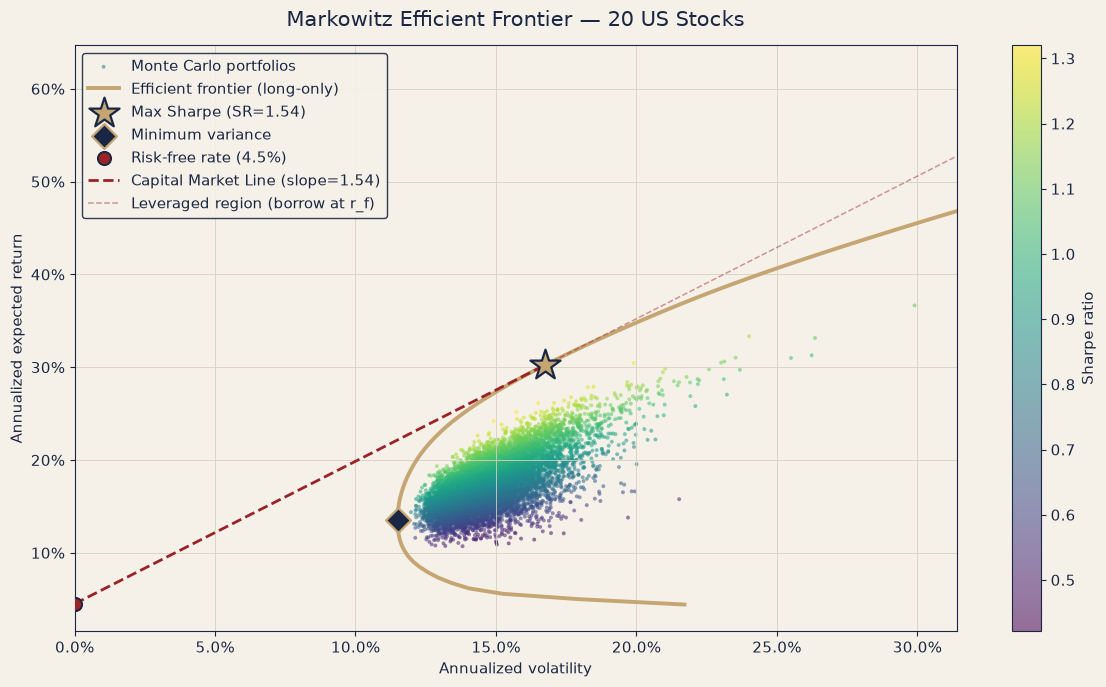

In [7]:
fig, ax = plt.subplots(figsize=(12, 7))

# Right edge of the x-axis (also reused for the CML so the line ends exactly at the boundary)
x_max = mc_volatility.max() * 1.05
CRIMSON = "#9b2226"   # contrasting colour for the CML and the risk-free point

# Monte Carlo cloud colored by Sharpe ratio (separate colormap: viridis)
sc = ax.scatter(
    mc_volatility, mc_returns,
    c=mc_sharpe, cmap="viridis",
    s=8, alpha=0.55, edgecolors="none",
    label="Monte Carlo portfolios",
)
cbar = fig.colorbar(sc, ax=ax)
cbar.set_label("Sharpe ratio", color=NAVY)
cbar.ax.yaxis.set_tick_params(color=NAVY)
plt.setp(cbar.ax.get_yticklabels(), color=NAVY)

# Long-only efficient frontier curve in gold (hugs the upper boundary of the cloud)
ax.plot(
    frontier_volatility, frontier_target,
    color=GOLD, linewidth=2.8, label="Efficient frontier (long-only)",
)

# Maximum-Sharpe (tangency) portfolio — gold star with navy edge
ax.scatter(
    tan_vol, tan_ret,
    marker="*", s=520, color=GOLD, edgecolors=NAVY, linewidths=1.6,
    zorder=5, label=f"Max Sharpe (SR={tan_sharpe:.2f})",
)

# Global Minimum-Variance portfolio — navy diamond
ax.scatter(
    gmv_vol, gmv_ret,
    marker="D", s=160, color=NAVY, edgecolors=GOLD, linewidths=1.6,
    zorder=5, label="Minimum variance",
)

# Risk-free point on the y-axis (zero volatility)
ax.scatter(
    0.0, RISK_FREE,
    marker="o", s=90, color=CRIMSON, edgecolors=NAVY, linewidths=1.4,
    zorder=6, label=f"Risk-free rate ({RISK_FREE:.1%})",
)

# Lock in the axis limits from the content above, so extending the CML to the
# right edge does not stretch the y-axis upward.
ax.set_xlim(0.0, x_max)
y_lo, y_hi = ax.get_ylim()
ax.set_ylim(y_lo, y_hi)

# Capital Market Line: starts at (0, risk-free), slope = max-Sharpe ratio,
# tangent to the frontier at the max-Sharpe portfolio. y = r_f + Sharpe * sigma.
# We draw it in two segments split at the tangency point:
#   - up to the tangency point: lending region (risk-free asset + tangency portfolio)
#   - beyond the tangency point: leveraged region (borrow at r_f to over-invest)
cml_x_lend = np.linspace(0.0, tan_vol, 50)    # zero volatility -> tangency point
cml_x_lev = np.linspace(tan_vol, x_max, 50)   # tangency point -> right edge of the chart
ax.plot(
    cml_x_lend, RISK_FREE + tan_sharpe * cml_x_lend,
    color=CRIMSON, linestyle="--", linewidth=2.0,
    label=f"Capital Market Line (slope={tan_sharpe:.2f})",
)
ax.plot(
    cml_x_lev, RISK_FREE + tan_sharpe * cml_x_lev,
    color=CRIMSON, linestyle="--", linewidth=1.1, alpha=0.45,
    label="Leveraged region (borrow at r_f)",
)

# Axis formatting as percentages
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
ax.set_xlabel("Annualized volatility")
ax.set_ylabel("Annualized expected return")
ax.set_title("Markowitz Efficient Frontier — 20 US Stocks", fontsize=15, pad=14)
ax.legend(loc="upper left", framealpha=0.9, facecolor=IVORY, edgecolor=NAVY)

plt.tight_layout()
plt.show()

## 8. Portfolio weights table

Finally we print the weights of both portfolios side by side (as percentages), sorted by the
max-Sharpe allocation. Since both portfolios are solved long-only, all weights are non-negative
(no short positions) and each column sums to 100%. Many stocks may receive a 0% allocation —
this is expected, as constrained optimization typically concentrates in a handful of names.

In [8]:
# Assemble both weight vectors into a single comparison table
weights_table = pd.DataFrame({
    "Min Variance": w_gmv,
    "Max Sharpe":   w_tan,
}, index=tickers)

# Sort by the max-Sharpe allocation and display as percentages
weights_table = weights_table.sort_values("Max Sharpe", ascending=False)

# Add a totals row to confirm each column sums to 100%
totals = pd.DataFrame(weights_table.sum()).T
totals.index = ["TOTAL"]
display_table = pd.concat([weights_table, totals])

(display_table * 100).round(2).astype(str) + " %"

,Min Variance,Max Sharpe
WMT,8.84 %,27.38 %
NVDA,0.76 %,18.7 %
CAT,1.35 %,16.97 %
XOM,5.26 %,14.69 %
JNJ,21.48 %,12.36 %
MRK,4.62 %,5.53 %
KO,15.28 %,4.36 %
AMZN,0.0 %,0.0 %
HON,0.19 %,0.0 %
AAPL,0.0 %,0.0 %


## 9. Constrained analysis — 15% per-asset cap

Real-world mandates often forbid concentrated bets. Here we repeat the analysis with an extra
constraint: **no single asset may exceed 15%** of the portfolio (`0 <= w_i <= 0.15`), while
keeping it long-only and fully invested. We re-solve the efficient frontier, the global
minimum-variance portfolio, and the max-Sharpe (tangency) portfolio under this cap.
The unconstrained results from sections 5-8 are left completely intact for comparison.

In [9]:
# Per-asset upper bound: no holding may exceed 15% (long-only, fully invested)
CAP = 0.15
bounds_capped = tuple((0.0, CAP) for _ in range(n_assets))   # 0 <= w_i <= 0.15

def min_variance_for_target_capped(target_return):
    """Minimize variance s.t. sum(w)=1, 0 <= w <= CAP, and w @ mu = target_return."""
    constraints = (
        {"type": "eq", "fun": lambda w: np.sum(w) - 1.0},          # budget constraint
        {"type": "eq", "fun": lambda w: w @ mu - target_return},   # target return constraint
    )
    return minimize(
        portfolio_variance, w0,
        method="SLSQP", bounds=bounds_capped, constraints=constraints,
        options={"ftol": 1e-12, "maxiter": 1000},
    )

# Solve the capped frontier across the same target grid. Capping the top performers
# lowers the maximum attainable return, so the highest targets become infeasible and drop out.
frontier_volatility_capped, frontier_target_capped = [], []
for target in np.linspace(mu.min(), mu.max(), 100):
    res = min_variance_for_target_capped(target)
    # Keep only solutions that actually converged and hit the target return
    if res.success and abs(res.x @ mu - target) < 1e-6:
        frontier_volatility_capped.append(np.sqrt(portfolio_variance(res.x)))
        frontier_target_capped.append(target)
frontier_volatility_capped = np.array(frontier_volatility_capped)
frontier_target_capped = np.array(frontier_target_capped)

# Capped global minimum-variance portfolio (bounds already enforce the 15% cap)
gmv_capped_res = minimize(
    portfolio_variance, w0,
    method="SLSQP", bounds=bounds_capped, constraints=budget_constraint,
    options={"ftol": 1e-12, "maxiter": 1000},
)
w_gmv_capped = gmv_capped_res.x
gmv_capped_ret, gmv_capped_vol, gmv_capped_sharpe = portfolio_stats(w_gmv_capped)

# Capped maximum-Sharpe (tangency) portfolio
tan_capped_res = minimize(
    negative_sharpe, w0,
    method="SLSQP", bounds=bounds_capped, constraints=budget_constraint,
    options={"ftol": 1e-12, "maxiter": 1000},
)
w_tan_capped = tan_capped_res.x
tan_capped_ret, tan_capped_vol, tan_capped_sharpe = portfolio_stats(w_tan_capped)

print(f"Capped frontier solved at {len(frontier_target_capped)} target levels.")
print("\n15%-capped Global Minimum-Variance portfolio:")
print(f"  Return = {gmv_capped_ret:.2%}   Volatility = {gmv_capped_vol:.2%}   Sharpe = {gmv_capped_sharpe:.3f}")
print("\n15%-capped Maximum-Sharpe (tangency) portfolio:")
print(f"  Return = {tan_capped_ret:.2%}   Volatility = {tan_capped_vol:.2%}   Sharpe = {tan_capped_sharpe:.3f}")

Capped frontier solved at 40 target levels.

15%-capped Global Minimum-Variance portfolio:
  Return = 13.40%   Volatility = 11.54%   Sharpe = 0.771

15%-capped Maximum-Sharpe (tangency) portfolio:
  Return = 27.18%   Volatility = 15.06%   Sharpe = 1.507


### Constrained chart (15% cap)

The same Monte Carlo cloud and styling as the first chart, now overlaid with the **capped**
frontier, its minimum-variance and max-Sharpe portfolios, and its own Capital Market Line —
including the same lending vs. leveraged-region distinction. Because the cap forbids large
single-name bets, the capped frontier sits below and to the right of the unconstrained one.

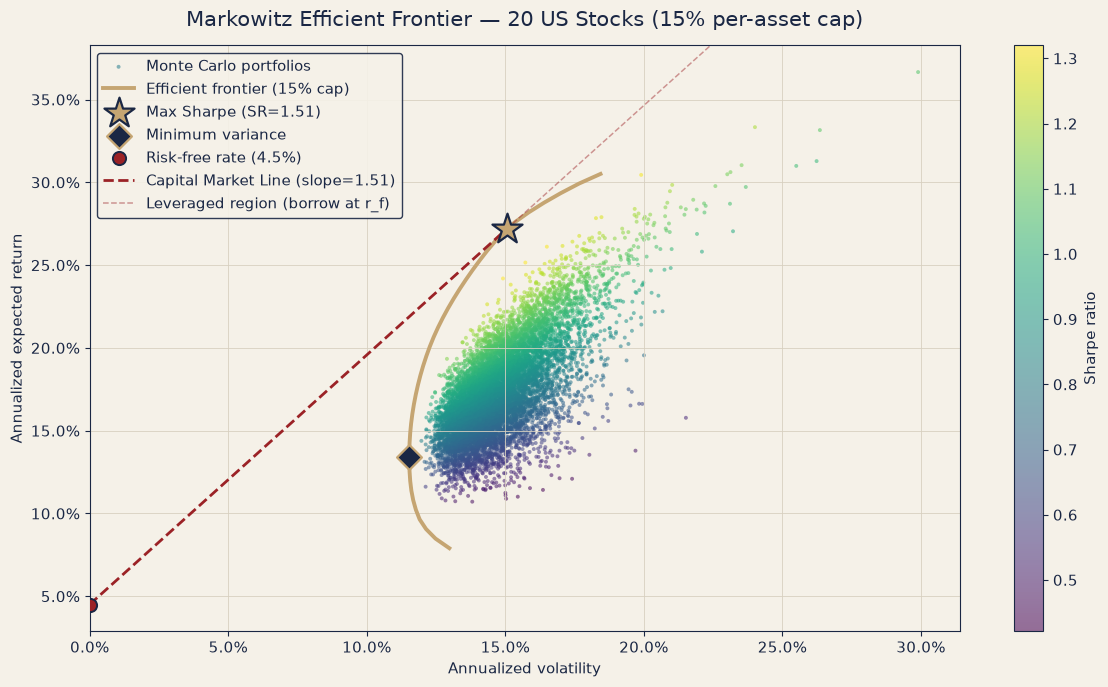

In [10]:
fig, ax = plt.subplots(figsize=(12, 7))

# Reuse the exact same right edge and CML colour as the first chart
x_max = mc_volatility.max() * 1.05
CRIMSON = "#9b2226"

# Same Monte Carlo cloud as the first chart (identical styling and colormap)
sc = ax.scatter(
    mc_volatility, mc_returns,
    c=mc_sharpe, cmap="viridis",
    s=8, alpha=0.55, edgecolors="none",
    label="Monte Carlo portfolios",
)
cbar = fig.colorbar(sc, ax=ax)
cbar.set_label("Sharpe ratio", color=NAVY)
cbar.ax.yaxis.set_tick_params(color=NAVY)
plt.setp(cbar.ax.get_yticklabels(), color=NAVY)

# Capped long-only efficient frontier in gold
ax.plot(
    frontier_volatility_capped, frontier_target_capped,
    color=GOLD, linewidth=2.8, label="Efficient frontier (15% cap)",
)

# Capped maximum-Sharpe (tangency) portfolio — gold star with navy edge
ax.scatter(
    tan_capped_vol, tan_capped_ret,
    marker="*", s=520, color=GOLD, edgecolors=NAVY, linewidths=1.6,
    zorder=5, label=f"Max Sharpe (SR={tan_capped_sharpe:.2f})",
)

# Capped global minimum-variance portfolio — navy diamond
ax.scatter(
    gmv_capped_vol, gmv_capped_ret,
    marker="D", s=160, color=NAVY, edgecolors=GOLD, linewidths=1.6,
    zorder=5, label="Minimum variance",
)

# Risk-free point on the y-axis (zero volatility)
ax.scatter(
    0.0, RISK_FREE,
    marker="o", s=90, color=CRIMSON, edgecolors=NAVY, linewidths=1.4,
    zorder=6, label=f"Risk-free rate ({RISK_FREE:.1%})",
)

# Lock in the axis limits before extending the CML to the right edge
ax.set_xlim(0.0, x_max)
y_lo, y_hi = ax.get_ylim()
ax.set_ylim(y_lo, y_hi)

# Capped Capital Market Line, split at the tangency point (same style as chart 1)
cml_x_lend = np.linspace(0.0, tan_capped_vol, 50)     # zero volatility -> tangency point
cml_x_lev = np.linspace(tan_capped_vol, x_max, 50)    # tangency point -> right edge
ax.plot(
    cml_x_lend, RISK_FREE + tan_capped_sharpe * cml_x_lend,
    color=CRIMSON, linestyle="--", linewidth=2.0,
    label=f"Capital Market Line (slope={tan_capped_sharpe:.2f})",
)
ax.plot(
    cml_x_lev, RISK_FREE + tan_capped_sharpe * cml_x_lev,
    color=CRIMSON, linestyle="--", linewidth=1.1, alpha=0.45,
    label="Leveraged region (borrow at r_f)",
)

# Axis formatting as percentages
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
ax.set_xlabel("Annualized volatility")
ax.set_ylabel("Annualized expected return")
ax.set_title("Markowitz Efficient Frontier — 20 US Stocks (15% per-asset cap)", fontsize=15, pad=14)
ax.legend(loc="upper left", framealpha=0.9, facecolor=IVORY, edgecolor=NAVY)

plt.tight_layout()
plt.show()

## 10. Comparison — unconstrained vs 15%-capped max-Sharpe

Below we place the two tangency (max-Sharpe) portfolios side by side and summarize how the cap
changes concentration, the Sharpe ratio, and the reachable frontier. A short interpretation note
follows the table.

In [11]:
# Side-by-side max-Sharpe weights: unconstrained vs 15%-capped
compare = pd.DataFrame({
    "Unconstrained Max Sharpe": w_tan,
    "15%-Capped Max Sharpe":    w_tan_capped,
}, index=tickers).sort_values("Unconstrained Max Sharpe", ascending=False)

# Confirm both columns sum to 100%
totals = pd.DataFrame(compare.sum()).T
totals.index = ["TOTAL"]
compare_display = pd.concat([compare, totals])

# --- Concentration / Sharpe / frontier-reach summary ---
THRESH = 0.001   # count a holding as "non-zero" if it exceeds 0.1%
n_unc = int((w_tan > THRESH).sum())
n_cap = int((w_tan_capped > THRESH).sum())

print("Number of non-zero holdings (> 0.1%):")
print(f"  Unconstrained: {n_unc}    |    15% cap: {n_cap}")
print("\nLargest single weight:")
print(f"  Unconstrained: {w_tan.max():.1%}    |    15% cap: {w_tan_capped.max():.1%}")
print("\nMax-Sharpe ratio:")
print(f"  Unconstrained: {tan_sharpe:.3f}    |    15% cap: {tan_capped_sharpe:.3f}")
print("\nMax attainable frontier return:")
print(f"  Unconstrained: {frontier_target.max():.2%}    |    15% cap: {frontier_target_capped.max():.2%}")

# Show the side-by-side weights as percentages
(compare_display * 100).round(2).astype(str) + " %"

Number of non-zero holdings (> 0.1%):
  Unconstrained: 7    |    15% cap: 8

Largest single weight:
  Unconstrained: 27.4%    |    15% cap: 15.0%

Max-Sharpe ratio:
  Unconstrained: 1.536    |    15% cap: 1.507

Max attainable frontier return:
  Unconstrained: 61.80%    |    15% cap: 30.51%


,Unconstrained Max Sharpe,15%-Capped Max Sharpe
WMT,27.38 %,15.0 %
NVDA,18.7 %,15.0 %
CAT,16.97 %,15.0 %
XOM,14.69 %,15.0 %
JNJ,12.36 %,15.0 %
MRK,5.53 %,7.05 %
KO,4.36 %,14.18 %
AMZN,0.0 %,0.0 %
HON,0.0 %,0.0 %
AAPL,0.0 %,0.0 %


### Interpretation — effect of the 15% cap

**(a) Concentration / number of holdings.** The unconstrained max-Sharpe portfolio is concentrated:
7 non-zero names with a single position as large as **27.4%**. The 15% cap forces that top position
down to exactly **15.0%** (the cap binds) and spreads the freed weight across more names, so the
capped portfolio holds **8** non-zero positions. The effect is de-concentration — the cap trades a
few large bets for a slightly broader, more balanced book.

**(b) Max-Sharpe ratio.** Constraints can only hurt (or tie) the optimum, never help it, so the cap
lowers the best achievable Sharpe — but only slightly, from **1.536 → 1.507** (about a 2% relative
drop). The capped tangency portfolio also sits at lower return *and* lower volatility
(27.2% / 15.1% vs 30.2% / 16.8%), i.e. a milder risk-return profile for a small efficiency cost.

**(c) Frontier position.** The capped frontier lies **below and to the right** of the unconstrained
one — for any target return it requires at least as much volatility, since the cap removes the
option of loading heavily into the lowest-variance or highest-return names. The difference is most
dramatic at the top end: the unconstrained frontier reaches up to **61.8%** return (a single-stock
corner solution), whereas the capped frontier tops out near **30.5%**, because hitting higher
returns is impossible once no asset may exceed 15%. At the low-risk end the two nearly coincide
(the minimum-variance point barely moves: 13.6% → 13.4% return), since the GMV portfolio was already
fairly diversified and only lightly affected by the cap.

## 11. Tightening the cap — 15% vs 10% vs 8%

We now re-solve only the **max-Sharpe (tangency)** portfolio under progressively tighter per-asset
caps and compare against the uncapped case. For each level we report the max-Sharpe ratio, the
number of non-zero holdings, and the largest single weight. The existing charts above are left
untouched.

In [12]:
# Solve the max-Sharpe portfolio for a given per-asset cap and summarize it.
def max_sharpe_summary(cap):
    """Return (sharpe, n_holdings, max_weight) for the long-only max-Sharpe portfolio
    under a per-asset upper bound `cap` (use cap=1.0 for the uncapped case)."""
    cap_bounds = tuple((0.0, cap) for _ in range(n_assets))
    res = minimize(
        negative_sharpe, w0,
        method="SLSQP", bounds=cap_bounds, constraints=budget_constraint,
        options={"ftol": 1e-12, "maxiter": 1000},
    )
    w = res.x
    _, _, sharpe = portfolio_stats(w)
    n_holdings = int((w > 0.001).sum())   # count weights above 0.1%
    return sharpe, n_holdings, w.max()

# Sweep the caps: uncapped (1.0) plus 15%, 10%, 8%
cap_levels = [("Uncapped", 1.00), ("15% cap", 0.15), ("10% cap", 0.10), ("8% cap", 0.08)]

rows = []
for label, cap in cap_levels:
    sharpe, n_holdings, max_w = max_sharpe_summary(cap)
    rows.append({
        "Constraint": label,
        "Max-Sharpe ratio": round(sharpe, 3),
        "Non-zero holdings": n_holdings,
        "Largest weight": f"{max_w:.1%}",
    })

cap_comparison = pd.DataFrame(rows).set_index("Constraint")
cap_comparison

,Max-Sharpe ratio,Non-zero holdings,Largest weight
Constraint,,,
Uncapped,1.536,7,27.4%
15% cap,1.507,8,15.0%
10% cap,1.378,11,10.0%
8% cap,1.271,13,8.0%


### The cost of diversification

A dual-axis view of the trade-off table above: as the per-asset cap tightens (left to right), the
portfolio is forced to hold more names (right axis, navy) while the achievable max-Sharpe ratio
declines (left axis, gold). The widening gap is the efficiency "cost" paid for broader
diversification.

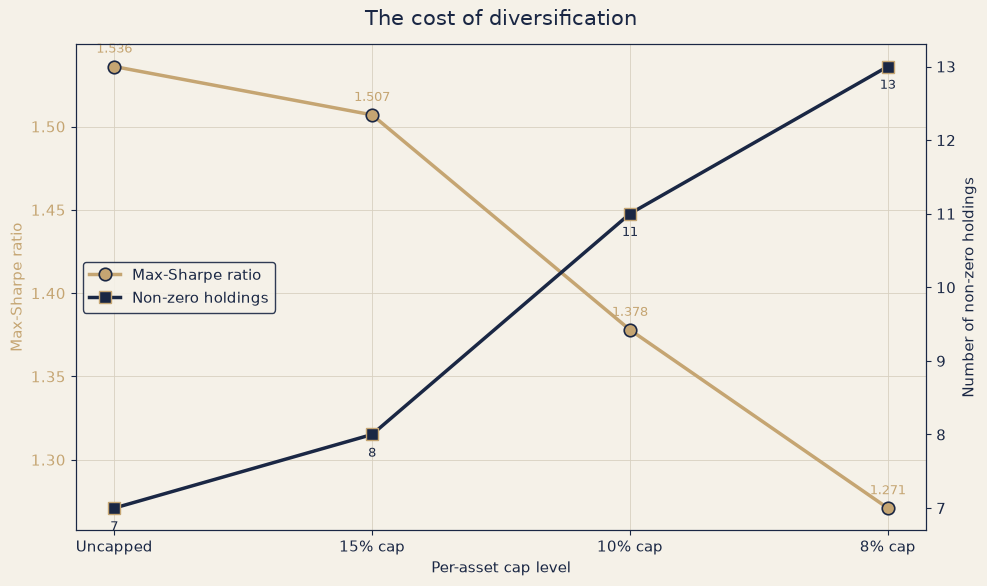

In [13]:
fig, ax_sharpe = plt.subplots(figsize=(10, 6))

# X-axis: cap levels in order from loosest (uncapped) to tightest (8%)
x_labels = cap_comparison.index.tolist()
x_pos = np.arange(len(x_labels))

# --- Left y-axis: max-Sharpe ratio (gold line) ---
sharpe_vals = cap_comparison["Max-Sharpe ratio"].values
ax_sharpe.plot(
    x_pos, sharpe_vals,
    color=GOLD, marker="o", markersize=9, linewidth=2.5,
    markeredgecolor=NAVY, markeredgewidth=1.2, label="Max-Sharpe ratio",
)
ax_sharpe.set_xlabel("Per-asset cap level")
ax_sharpe.set_ylabel("Max-Sharpe ratio", color=GOLD)
ax_sharpe.tick_params(axis="y", labelcolor=GOLD)
ax_sharpe.set_xticks(x_pos)
ax_sharpe.set_xticklabels(x_labels)

# --- Right y-axis: number of non-zero holdings (navy line) ---
ax_holdings = ax_sharpe.twinx()
holdings_vals = cap_comparison["Non-zero holdings"].values
ax_holdings.plot(
    x_pos, holdings_vals,
    color=NAVY, marker="s", markersize=8, linewidth=2.5,
    markeredgecolor=GOLD, markeredgewidth=1.0, label="Non-zero holdings",
)
ax_holdings.set_ylabel("Number of non-zero holdings", color=NAVY)
ax_holdings.tick_params(axis="y", labelcolor=NAVY)
ax_holdings.grid(False)   # keep only the left-axis gridlines for a clean look

# Annotate each point with its value for quick reading
for x, s in zip(x_pos, sharpe_vals):
    ax_sharpe.annotate(f"{s:.3f}", (x, s), textcoords="offset points",
                       xytext=(0, 10), ha="center", color=GOLD, fontsize=9)
for x, h in zip(x_pos, holdings_vals):
    ax_holdings.annotate(f"{h}", (x, h), textcoords="offset points",
                         xytext=(0, -16), ha="center", color=NAVY, fontsize=9)

# Combined legend from both axes
lines_l, labels_l = ax_sharpe.get_legend_handles_labels()
lines_r, labels_r = ax_holdings.get_legend_handles_labels()
ax_sharpe.legend(lines_l + lines_r, labels_l + labels_r,
                 loc="center left", framealpha=0.9, facecolor=IVORY, edgecolor=NAVY)

ax_sharpe.set_title("The cost of diversification", fontsize=15, pad=14)
plt.tight_layout()
plt.show()

## 12. All four frontiers overlaid

Finally we draw the efficient frontiers for all four cap levels on one set of axes, shaded from gold
(loosest) to navy (tightest). Tighter caps pull the frontier **inward** (more volatility is needed
for any given return) and **shorten its right end** (the maximum attainable return falls, because no
single high-return name can dominate the portfolio).

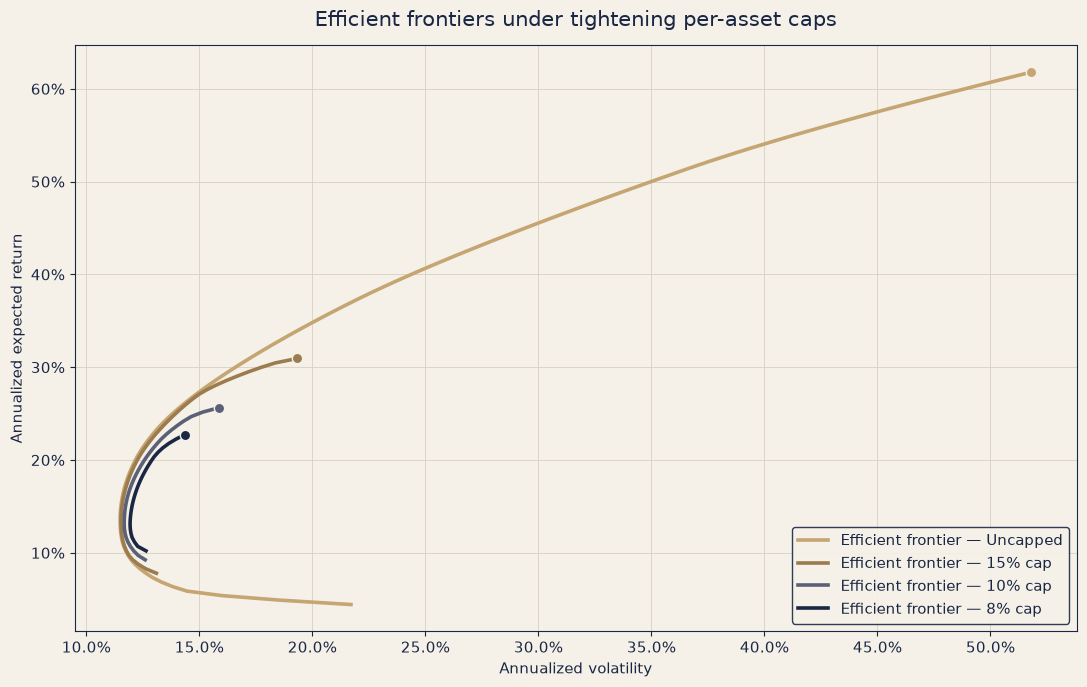

In [14]:
def solve_frontier(cap, n_points=120):
    """Solve the long-only efficient frontier under a per-asset cap.
    Returns (volatilities, returns) for the target levels that are feasible."""
    cap_bounds = tuple((0.0, cap) for _ in range(n_assets))
    vols, rets = [], []
    for target in np.linspace(mu.min(), mu.max(), n_points):
        constraints = (
            {"type": "eq", "fun": lambda w: np.sum(w) - 1.0},               # budget
            {"type": "eq", "fun": lambda w, t=target: w @ mu - t},          # target return
        )
        res = minimize(
            portfolio_variance, w0,
            method="SLSQP", bounds=cap_bounds, constraints=constraints,
            options={"ftol": 1e-12, "maxiter": 1000},
        )
        if res.success and abs(res.x @ mu - target) < 1e-6:
            vols.append(np.sqrt(portfolio_variance(res.x)))
            rets.append(target)
    return np.array(vols), np.array(rets)

# Cap levels shaded from gold (loosest) to navy (tightest)
frontier_specs = [
    ("Uncapped", 1.00, "#c5a572"),   # gold
    ("15% cap",  0.15, "#9c7b4f"),   # dark gold / bronze
    ("10% cap",  0.10, "#5a6076"),   # slate (gold -> navy midpoint)
    ("8% cap",   0.08, "#1a2744"),   # navy
]

fig, ax = plt.subplots(figsize=(11, 7))

for label, cap, color in frontier_specs:
    vols, rets = solve_frontier(cap)
    ax.plot(
        vols, rets,
        color=color, linewidth=2.6,
        label=f"Efficient frontier — {label}",
    )
    # Mark the right end (max attainable return) of each frontier
    ax.scatter(vols[-1], rets[-1], color=color, s=55,
               edgecolors=IVORY, linewidths=1.0, zorder=5)

# Axis formatting as percentages (same axes meaning as the earlier frontier charts)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
ax.set_xlabel("Annualized volatility")
ax.set_ylabel("Annualized expected return")
ax.set_title("Efficient frontiers under tightening per-asset caps", fontsize=15, pad=14)
ax.legend(loc="lower right", framealpha=0.9, facecolor=IVORY, edgecolor=NAVY)

plt.tight_layout()
plt.show()

## 13. In-sample realized performance of the four max-Sharpe portfolios

We take the four max-Sharpe weight vectors (uncapped, 15%, 10%, 8%) and replay them over the same
5-year daily history to see their realized return paths, drawdowns, and risk statistics.

> ⚠️ **This is an IN-SAMPLE exercise.** The weights were optimized on *exactly this same period*, so
> the cumulative paths are **not** a genuine out-of-sample backtest — they suffer from look-ahead /
> optimization bias and will flatter the optimized portfolios. They are shown only to illustrate the
> realized risk/return *journey* and the drawdown profiles implied by each set of weights, **not** as
> evidence of future performance. A true test would re-estimate the weights on a training window and
> evaluate on a later, untouched window.

In [15]:
# Re-solve the max-Sharpe weights for each cap and collect the weight vectors
def max_sharpe_weights(cap):
    """Long-only max-Sharpe weights under a per-asset upper bound `cap`."""
    cap_bounds = tuple((0.0, cap) for _ in range(n_assets))
    res = minimize(
        negative_sharpe, w0,
        method="SLSQP", bounds=cap_bounds, constraints=budget_constraint,
        options={"ftol": 1e-12, "maxiter": 1000},
    )
    return res.x

# Each portfolio: (label, cap, plot colour) shaded gold (loosest) -> navy (tightest)
portfolio_defs = [
    ("Uncapped", 1.00, "#c5a572"),   # gold
    ("15% cap",  0.15, "#9c7b4f"),   # dark gold / bronze
    ("10% cap",  0.10, "#5a6076"),   # slate
    ("8% cap",   0.08, "#1a2744"),   # navy
]

# In-sample daily portfolio returns: weights applied to the SAME 5-year daily returns.
# daily_returns columns are already in `tickers` order, matching the weight vectors.
port_daily = pd.DataFrame(
    {label: daily_returns.values @ max_sharpe_weights(cap)
     for label, cap, _ in portfolio_defs},
    index=daily_returns.index,
)

# Cumulative growth of $1 for each portfolio
cum_growth = (1 + port_daily).cumprod()

print(f"Replayed {port_daily.shape[0]} daily observations for {port_daily.shape[1]} portfolios.")
print("Final growth of $1:")
print((cum_growth.iloc[-1]).round(3).to_string())

Replayed 1253 daily observations for 4 portfolios.
Final growth of $1:
Uncapped    4.191
15% cap     3.650
10% cap     3.212
8% cap      2.893


### (1) Cumulative return chart

Growth of $1 invested at the start of the window, for all four portfolios on one plot.

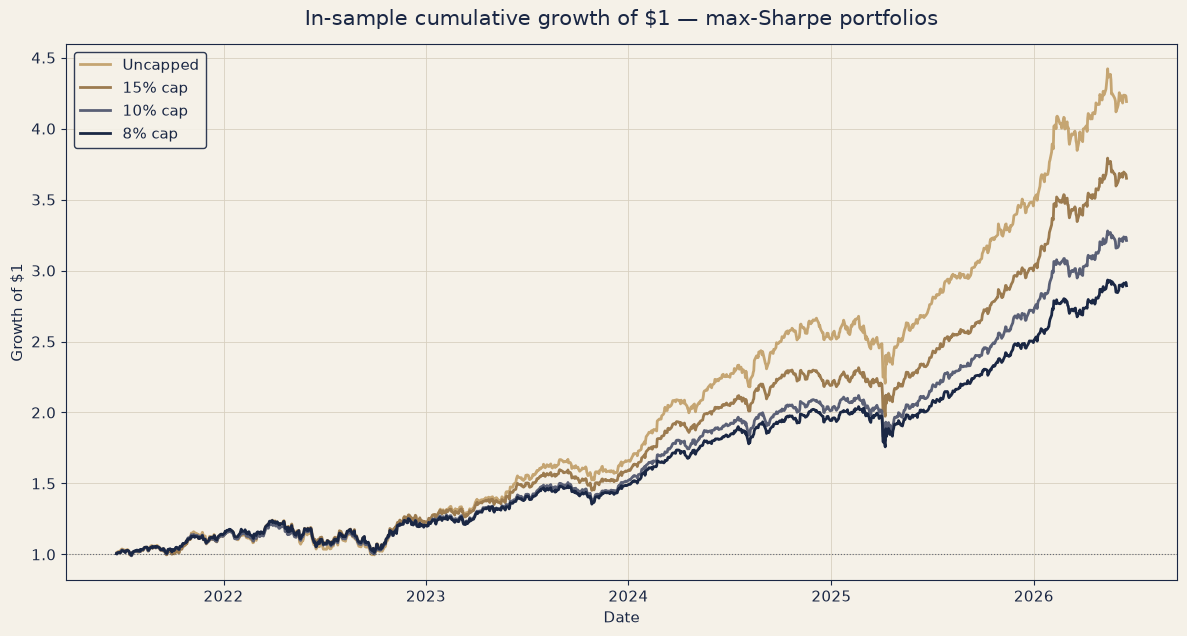

In [16]:
fig, ax = plt.subplots(figsize=(12, 6.5))

# One cumulative-growth line per portfolio, using the Merivale gold -> navy shades
for label, cap, color in portfolio_defs:
    ax.plot(cum_growth.index, cum_growth[label], color=color, linewidth=2.0, label=label)

ax.axhline(1.0, color=NAVY, linewidth=0.8, linestyle=":", alpha=0.6)  # break-even ($1)
ax.set_xlabel("Date")
ax.set_ylabel("Growth of $1")
ax.set_title("In-sample cumulative growth of $1 — max-Sharpe portfolios", fontsize=15, pad=14)
ax.legend(loc="upper left", framealpha=0.9, facecolor=IVORY, edgecolor=NAVY)

plt.tight_layout()
plt.show()

### (2) Drawdown (underwater) chart

For each portfolio, the drawdown at time *t* is its decline from the highest cumulative value
reached up to *t*. The shaded "underwater" area shows how deep and how long each portfolio stayed
below its prior peak.

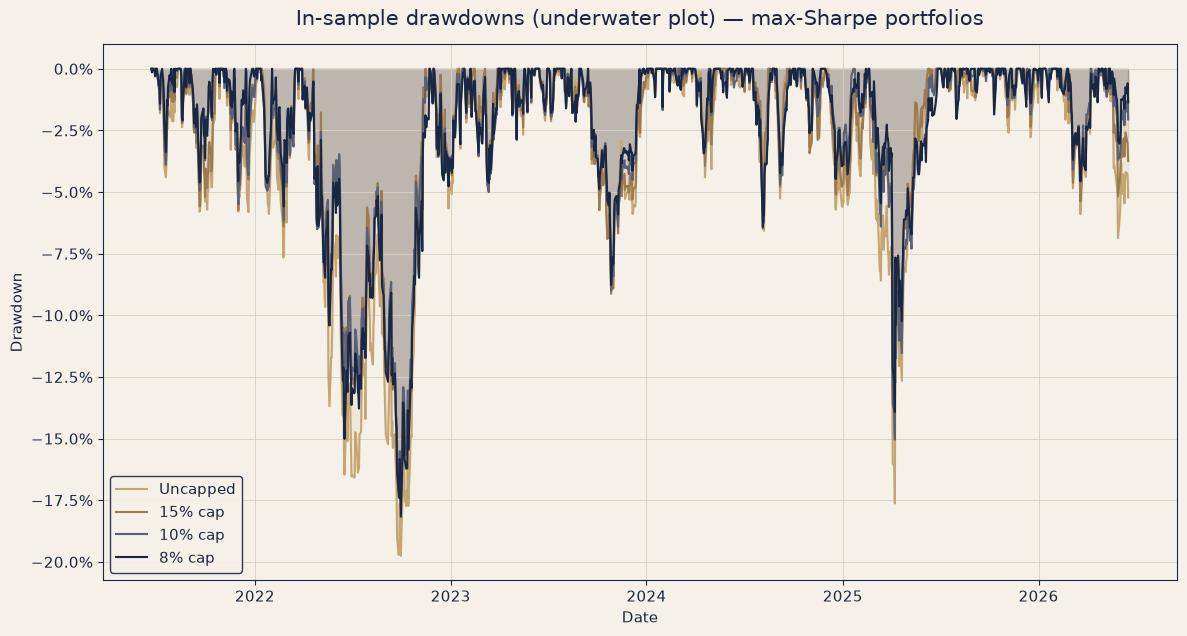

In [17]:
fig, ax = plt.subplots(figsize=(12, 6.5))

# Drawdown = current cumulative value / running peak - 1 (always <= 0)
for label, cap, color in portfolio_defs:
    cum = cum_growth[label]
    drawdown = cum / cum.cummax() - 1.0
    ax.plot(drawdown.index, drawdown, color=color, linewidth=1.5, label=label)
    ax.fill_between(drawdown.index, drawdown, 0.0, color=color, alpha=0.12)

ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
ax.set_xlabel("Date")
ax.set_ylabel("Drawdown")
ax.set_title("In-sample drawdowns (underwater plot) — max-Sharpe portfolios", fontsize=15, pad=14)
ax.legend(loc="lower left", framealpha=0.9, facecolor=IVORY, edgecolor=NAVY)

plt.tight_layout()
plt.show()

### (3) Summary statistics table

Realized performance metrics for each portfolio. Ratios use a risk-free rate of 4.5%; Sortino uses
downside deviation relative to a 0% daily target; Calmar = CAGR / |max drawdown|. Longest drawdown
duration is measured in calendar days from a peak until that peak is recovered.

In [18]:
def performance_stats(r):
    """Realized performance statistics for a daily return series `r`."""
    r = r.dropna()
    n = len(r)
    years = n / TRADING_DAYS

    cum = (1 + r).cumprod()
    total_return = cum.iloc[-1] - 1.0
    cagr = cum.iloc[-1] ** (1 / years) - 1.0

    ann_mean = r.mean() * TRADING_DAYS                 # annualized arithmetic return
    ann_vol = r.std(ddof=1) * np.sqrt(TRADING_DAYS)    # realized annual volatility
    sharpe = (ann_mean - RISK_FREE) / ann_vol

    # Downside deviation relative to a 0% daily target, annualized
    downside_dev = np.sqrt(np.mean(np.minimum(r, 0.0) ** 2)) * np.sqrt(TRADING_DAYS)
    sortino = (ann_mean - RISK_FREE) / downside_dev

    # Drawdown series and maximum drawdown
    drawdown = cum / cum.cummax() - 1.0
    max_dd = drawdown.min()
    calmar = cagr / abs(max_dd)

    # Longest drawdown duration: calendar days from a peak until that peak is recovered
    longest_dd_days = 0
    last_peak_date = cum.index[0]
    for date, d in drawdown.items():
        if d >= 0:                                     # at or above the prior peak
            last_peak_date = date
        else:
            longest_dd_days = max(longest_dd_days, (date - last_peak_date).days)

    return {
        "Total return": total_return,
        "CAGR": cagr,
        "Ann. volatility": ann_vol,
        "Sharpe (rf=4.5%)": sharpe,
        "Sortino": sortino,
        "Calmar": calmar,
        "Max drawdown": max_dd,
        "Longest DD (days)": longest_dd_days,
        "Best day": r.max(),
        "Worst day": r.min(),
    }

# Build the metrics table: rows = metrics, columns = portfolios
stats = pd.DataFrame({label: performance_stats(port_daily[label])
                      for label, _, _ in portfolio_defs})

# Format each row appropriately (percentages, ratios, or integer days)
pct_rows = ["Total return", "CAGR", "Ann. volatility", "Max drawdown", "Best day", "Worst day"]
ratio_rows = ["Sharpe (rf=4.5%)", "Sortino", "Calmar"]

formatted = stats.copy().astype(object)
for row in stats.index:
    for col in stats.columns:
        v = stats.loc[row, col]
        if row in pct_rows:
            formatted.loc[row, col] = f"{v:.2%}"
        elif row in ratio_rows:
            formatted.loc[row, col] = f"{v:.3f}"
        else:  # Longest DD (days)
            formatted.loc[row, col] = f"{int(v)}"

formatted

,Uncapped,15% cap,10% cap,8% cap
Total return,319.07%,265.02%,221.19%,189.33%
CAGR,33.40%,29.75%,26.45%,23.82%
Ann. volatility,16.75%,15.06%,14.54%,14.06%
Sharpe (rf=4.5%),1.536,1.507,1.378,1.271
Sortino,2.356,2.303,2.089,1.910
Calmar,1.691,1.687,1.498,1.312
Max drawdown,-19.75%,-17.63%,-17.66%,-18.16%
Longest DD (days),236,229,236,237
Best day,8.91%,7.52%,7.28%,7.27%
Worst day,-5.71%,-5.53%,-5.73%,-5.92%


## 14. Out-of-sample test (train / test split)

Unlike section 13, this is a **proper out-of-sample test**. We split the 5-year daily history into:

- **Training period — first 4 years:** used *only* to estimate expected returns / covariance and to
  re-optimize the four max-Sharpe portfolios (uncapped, 15%, 10%, 8%).
- **Test period — last 1 year:** the weights are then **frozen** and their realized performance is
  measured here, on data the optimizer never saw.

We also add an **equal-weight (1/N) portfolio** as a naive benchmark — a notoriously hard one to beat
out-of-sample. **All optimized weights come from the training data; all performance below is measured
out-of-sample on the test year.**

In [19]:
# --- Split the daily data: first 4 years = training, last 1 year = test ---
test_start = daily_returns.index.max() - pd.DateOffset(years=1)
train_returns = daily_returns[daily_returns.index < test_start]
test_returns  = daily_returns[daily_returns.index >= test_start]

print(f"Training: {train_returns.index.min().date()} -> {train_returns.index.max().date()} "
      f"({len(train_returns)} days)")
print(f"Test:     {test_returns.index.min().date()} -> {test_returns.index.max().date()} "
      f"({len(test_returns)} days)")

# --- Estimate inputs from TRAINING data only ---
mu_train = train_returns.mean().values * TRADING_DAYS
Sigma_train = train_returns.cov().values * TRADING_DAYS

def neg_sharpe_train(weights):
    """Negative Sharpe ratio using TRAINING-period mu/Sigma (for optimization)."""
    ret = weights @ mu_train
    vol = np.sqrt(weights @ Sigma_train @ weights)
    return -(ret - RISK_FREE) / vol

def max_sharpe_weights_train(cap):
    """Long-only max-Sharpe weights under a per-asset cap, fitted on training data."""
    cap_bounds = tuple((0.0, cap) for _ in range(n_assets))
    res = minimize(
        neg_sharpe_train, w0,
        method="SLSQP", bounds=cap_bounds, constraints=budget_constraint,
        options={"ftol": 1e-12, "maxiter": 1000},
    )
    return res.x

# Portfolio set: four cap levels (gold -> navy) + equal-weight benchmark (crimson)
oos_defs = [
    ("Uncapped",           1.00, "#c5a572"),
    ("15% cap",            0.15, "#9c7b4f"),
    ("10% cap",            0.10, "#5a6076"),
    ("8% cap",             0.08, "#1a2744"),
]

# Weights fitted on training data; equal-weight needs no fitting
weights_oos = {label: max_sharpe_weights_train(cap) for label, cap, _ in oos_defs}
weights_oos["Equal-weight (1/N)"] = np.ones(n_assets) / n_assets

# Plot order/colours including the benchmark
oos_plot = oos_defs + [("Equal-weight (1/N)", None, "#9b2226")]

# --- Apply the FROZEN weights to the TEST period only (out-of-sample) ---
oos_daily = pd.DataFrame(
    {label: test_returns.values @ w for label, w in weights_oos.items()},
    index=test_returns.index,
)
oos_cum = (1 + oos_daily).cumprod()

print("\nOut-of-sample final growth of $1 (test year):")
print(oos_cum.iloc[-1].round(3).to_string())

Training: 2021-06-22 -> 2025-06-16 (1001 days)
Test:     2025-06-17 -> 2026-06-17 (252 days)

Out-of-sample final growth of $1 (test year):
Uncapped              1.342
15% cap               1.226
10% cap               1.249
8% cap                1.276
Equal-weight (1/N)    1.298


### Out-of-sample cumulative return chart (test year)

Growth of $1 over the test year using the **training-fitted, frozen weights**, with the equal-weight
benchmark shown as a dashed crimson line.

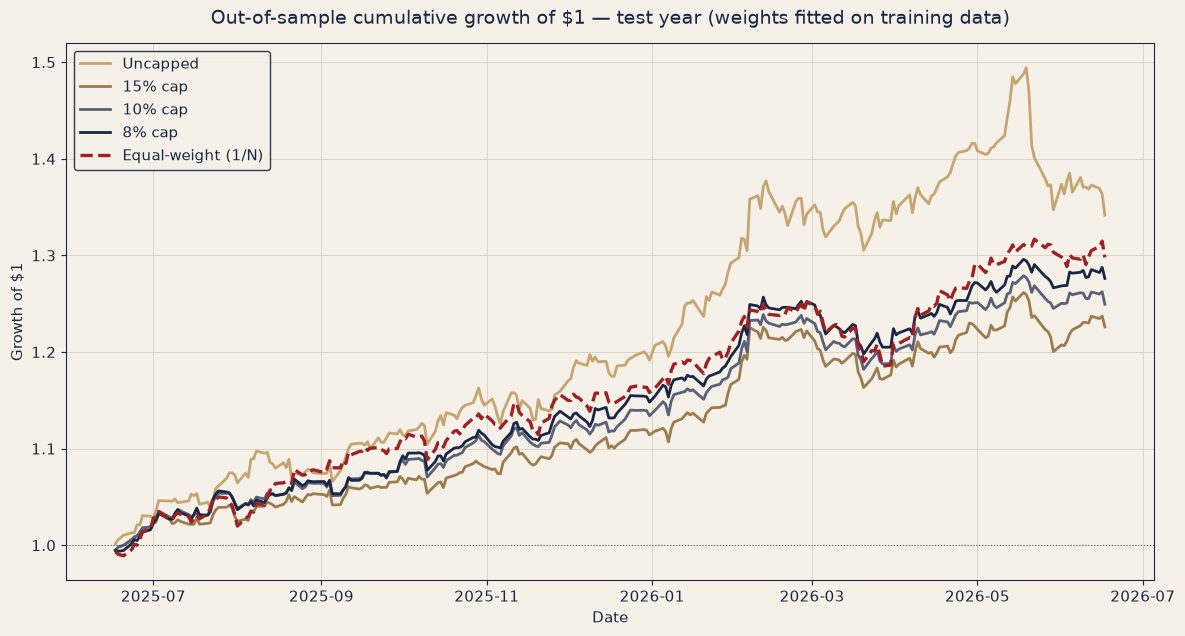

In [20]:
fig, ax = plt.subplots(figsize=(12, 6.5))

# One line per portfolio; the equal-weight benchmark is dashed to stand out
for label, cap, color in oos_plot:
    style = "--" if label.startswith("Equal-weight") else "-"
    lw = 2.4 if label.startswith("Equal-weight") else 2.0
    ax.plot(oos_cum.index, oos_cum[label], color=color, linewidth=lw, linestyle=style, label=label)

ax.axhline(1.0, color=NAVY, linewidth=0.8, linestyle=":", alpha=0.6)  # break-even ($1)
ax.set_xlabel("Date")
ax.set_ylabel("Growth of $1")
ax.set_title("Out-of-sample cumulative growth of $1 — test year (weights fitted on training data)",
             fontsize=14, pad=14)
ax.legend(loc="upper left", framealpha=0.9, facecolor=IVORY, edgecolor=NAVY)

plt.tight_layout()
plt.show()

### Out-of-sample summary statistics (test year)

Realized test-period metrics for each portfolio plus the equal-weight benchmark. Same definitions as
section 13 (rf = 4.5%; Sortino vs a 0% daily target; Calmar = CAGR / |max drawdown|). CAGR over a
~1-year window is close to the total return.

In [21]:
# Reuse performance_stats() from section 13, keeping only the requested metrics
oos_metrics = ["Total return", "CAGR", "Ann. volatility",
               "Sharpe (rf=4.5%)", "Sortino", "Calmar", "Max drawdown"]

oos_stats = pd.DataFrame(
    {label: performance_stats(oos_daily[label]) for label in oos_daily.columns}
).loc[oos_metrics]

# Format: percentages for return/vol/drawdown rows, 3 decimals for the ratio rows
oos_pct_rows = ["Total return", "CAGR", "Ann. volatility", "Max drawdown"]
oos_formatted = oos_stats.copy().astype(object)
for row in oos_stats.index:
    for col in oos_stats.columns:
        v = oos_stats.loc[row, col]
        oos_formatted.loc[row, col] = f"{v:.2%}" if row in oos_pct_rows else f"{v:.3f}"

oos_formatted

,Uncapped,15% cap,10% cap,8% cap,Equal-weight (1/N)
Total return,34.16%,22.60%,24.94%,27.61%,29.79%
CAGR,34.16%,22.60%,24.94%,27.61%,29.79%
Ann. volatility,13.42%,8.74%,8.26%,8.46%,9.06%
Sharpe (rf=4.5%),1.922,1.861,2.193,2.394,2.429
Sortino,2.903,2.943,3.578,4.031,3.952
Calmar,3.341,4.436,5.443,5.892,5.620
Max drawdown,-10.22%,-5.09%,-4.58%,-4.69%,-5.30%


## 15. Walk-forward (rolling out-of-sample) backtest

The single train/test split in section 14 depends heavily on one arbitrary cut date. A **walk-forward**
backtest is more robust: we repeatedly re-optimize on a rolling lookback window and evaluate on the
period immediately after, then roll forward.

**Protocol**
- **Lookback:** trailing **3 years** of daily data used to optimize the portfolios.
- **Rebalance:** every **3 months**. At each rebalance date we re-fit the four max-Sharpe portfolios
  (uncapped, 15%, 10%, 8%) on the trailing 3 years, hold those weights for the next 3 months, then
  roll forward. Equal-weight (1/N) is held constant.
- **Stitching:** each 3-month hold period is genuinely out-of-sample (the weights never saw it); we
  concatenate these consecutive hold periods into one continuous OOS performance series per portfolio.

Because we have 5 years of data and need a 3-year lookback before the first rebalance, the
out-of-sample period spans roughly the final 2 years. **All weights are fitted only on the trailing
lookback window; all performance is measured out-of-sample.** **There are 8 rebalance windows** in this backtest, covering the out-of-sample span from
June 2024 to June 2026 (498 trading days).

In [22]:
# Walk-forward parameters
LOOKBACK = pd.DateOffset(years=3)   # trailing window used for optimization
STEP = pd.DateOffset(months=3)      # rebalance frequency

idx = daily_returns.index

# Build the rebalance dates: start once 3 years of history is available,
# then step forward every 3 months until we run out of data.
rebal_dates = []
d = idx.min() + LOOKBACK
while d < idx.max():
    pos = idx.searchsorted(d)            # snap to first trading day on/after d
    if pos < len(idx):
        rebal_dates.append(idx[pos])
    d = d + STEP
rebal_dates = list(dict.fromkeys(rebal_dates))   # drop accidental duplicates, keep order

# Optimize long-only max-Sharpe on a training slice under a per-asset cap
def optimize_max_sharpe(train_slice, cap):
    mu_t = train_slice.mean().values * TRADING_DAYS
    sig_t = train_slice.cov().values * TRADING_DAYS
    cap_bounds = tuple((0.0, cap) for _ in range(n_assets))
    def neg_sharpe(w):
        ret = w @ mu_t
        vol = np.sqrt(w @ sig_t @ w)
        return -(ret - RISK_FREE) / vol
    res = minimize(neg_sharpe, w0, method="SLSQP",
                   bounds=cap_bounds, constraints=budget_constraint,
                   options={"ftol": 1e-12, "maxiter": 1000})
    return res.x

# Five portfolios: four cap levels (gold -> navy) + equal-weight benchmark (crimson)
wf_defs = [
    ("Uncapped",           1.00, "#c5a572"),
    ("15% cap",            0.15, "#9c7b4f"),
    ("10% cap",            0.10, "#5a6076"),
    ("8% cap",             0.08, "#1a2744"),
    ("Equal-weight (1/N)", None, "#9b2226"),
]

# Walk-forward loop: optimize on trailing window, hold over the next quarter
oos_pieces = {label: [] for label, _, _ in wf_defs}
period_records = []

for i, r in enumerate(rebal_dates):
    hold_end = rebal_dates[i + 1] if i + 1 < len(rebal_dates) else idx.max() + pd.Timedelta(days=1)
    train_slice = daily_returns[(idx >= r - LOOKBACK) & (idx < r)]
    hold_slice = daily_returns[(idx >= r) & (idx < hold_end)]
    if len(hold_slice) == 0:
        continue

    period_sharpes = {}
    for label, cap, _ in wf_defs:
        w = np.ones(n_assets) / n_assets if cap is None else optimize_max_sharpe(train_slice, cap)
        port_ret = pd.Series(hold_slice.values @ w, index=hold_slice.index)
        oos_pieces[label].append(port_ret)
        sd = port_ret.std(ddof=1)
        period_sharpes[label] = ((port_ret.mean() * TRADING_DAYS - RISK_FREE) /
                                 (sd * np.sqrt(TRADING_DAYS))) if sd > 0 else float("nan")

    rec = {"Rebalance": r.date(),
           "Hold start": hold_slice.index.min().date(),
           "Hold end": hold_slice.index.max().date()}
    rec.update(period_sharpes)
    rec["Best Sharpe"] = max(period_sharpes, key=period_sharpes.get)
    period_records.append(rec)

# Stitch consecutive hold periods into one continuous OOS series per portfolio
wf_daily = pd.DataFrame({label: pd.concat(pieces) for label, pieces in oos_pieces.items()})
wf_cum = (1 + wf_daily).cumprod()

n_windows = len(period_records)
print(f"Number of rebalance windows: {n_windows}")
print(f"Out-of-sample span: {wf_daily.index.min().date()} -> {wf_daily.index.max().date()} "
      f"({len(wf_daily)} trading days)")
print("\nStitched final growth of $1:")
print(wf_cum.iloc[-1].round(3).to_string())

Number of rebalance windows: 8
Out-of-sample span: 2024-06-24 -> 2026-06-17 (498 trading days)

Stitched final growth of $1:
Uncapped              1.398
15% cap               1.424
10% cap               1.421
8% cap                1.377
Equal-weight (1/N)    1.414


### (1) Walk-forward cumulative return chart

Growth of $1 over the stitched out-of-sample series for all five portfolios. The equal-weight
benchmark is the dashed crimson line.

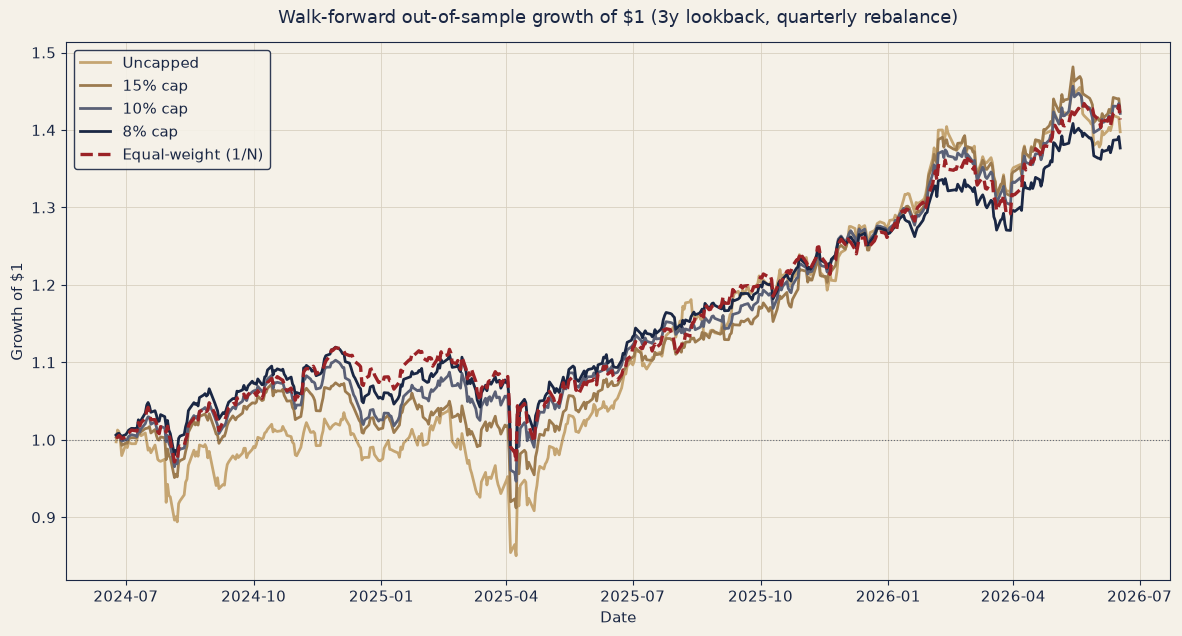

In [23]:
fig, ax = plt.subplots(figsize=(12, 6.5))

# One line per portfolio; equal-weight benchmark dashed to stand out
for label, cap, color in wf_defs:
    style = "--" if label.startswith("Equal-weight") else "-"
    lw = 2.4 if label.startswith("Equal-weight") else 2.0
    ax.plot(wf_cum.index, wf_cum[label], color=color, linewidth=lw, linestyle=style, label=label)

ax.axhline(1.0, color=NAVY, linewidth=0.8, linestyle=":", alpha=0.6)  # break-even ($1)
ax.set_xlabel("Date")
ax.set_ylabel("Growth of $1")
ax.set_title("Walk-forward out-of-sample growth of $1 (3y lookback, quarterly rebalance)",
             fontsize=13, pad=14)
ax.legend(loc="upper left", framealpha=0.9, facecolor=IVORY, edgecolor=NAVY)

plt.tight_layout()
plt.show()

### (2) Walk-forward summary statistics

Realized statistics over the full stitched out-of-sample period. Same definitions as section 13
(rf = 4.5%; Sortino vs a 0% daily target; Calmar = CAGR / |max drawdown|).

In [24]:
# Reuse performance_stats() from section 13 over the stitched OOS series
wf_metrics = ["Total return", "CAGR", "Ann. volatility",
              "Sharpe (rf=4.5%)", "Sortino", "Calmar", "Max drawdown"]

wf_stats = pd.DataFrame(
    {label: performance_stats(wf_daily[label]) for label in wf_daily.columns}
).loc[wf_metrics]

wf_pct_rows = ["Total return", "CAGR", "Ann. volatility", "Max drawdown"]
wf_formatted = wf_stats.copy().astype(object)
for row in wf_stats.index:
    for col in wf_stats.columns:
        v = wf_stats.loc[row, col]
        wf_formatted.loc[row, col] = f"{v:.2%}" if row in wf_pct_rows else f"{v:.3f}"

wf_formatted

,Uncapped,15% cap,10% cap,8% cap,Equal-weight (1/N)
Total return,39.76%,42.45%,42.14%,37.67%,41.35%
CAGR,18.46%,19.61%,19.47%,17.56%,19.14%
Ann. volatility,17.88%,14.44%,13.18%,12.35%,12.57%
Sharpe (rf=4.5%),0.785,1.000,1.075,1.008,1.099
Sortino,1.152,1.493,1.615,1.509,1.668
Calmar,1.006,1.303,1.374,1.376,1.454
Max drawdown,-18.36%,-15.04%,-14.17%,-12.76%,-13.16%


### (3) Which portfolio won each rebalance period?

For every 3-month hold period we show each portfolio's realized (annualized) Sharpe ratio and flag
the winner in the **Best Sharpe** column. The win-count summary above the table shows how often the
naive 1/N benchmark beats the optimized portfolios out-of-sample.

In [25]:
labels = [l for l, _, _ in wf_defs]
period_df = pd.DataFrame(period_records)[["Rebalance", "Hold start", "Hold end"] + labels + ["Best Sharpe"]]

# How often each portfolio had the highest period Sharpe
print(f"Best-Sharpe wins across {len(period_df)} rebalance windows:")
print(period_df["Best Sharpe"].value_counts().to_string())

# Per-period annualized Sharpe (2 decimals), with the winning portfolio flagged
period_fmt = period_df.copy()
for l in labels:
    period_fmt[l] = period_df[l].map(lambda v: f"{v:.2f}")
period_fmt

Best-Sharpe wins across 8 rebalance windows:
Best Sharpe
Equal-weight (1/N)    3
15% cap               2
8% cap                1
10% cap               1
Uncapped              1


,Rebalance,Hold start,Hold end,Uncapped,15% cap,10% cap,8% cap,Equal-weight (1/N),Best Sharpe
0,2024-06-24,2024-06-24,2024-09-20,-0.52,0.62,1.20,1.73,1.52,8% cap
1,2024-09-23,2024-09-23,2024-12-20,-0.34,-1.03,-1.18,-0.68,0.54,Equal-weight (1/N)
2,2024-12-23,2024-12-23,2025-03-21,-0.86,-0.18,0.49,0.21,-0.45,10% cap
3,2025-03-24,2025-03-24,2025-06-20,1.34,0.75,0.51,0.27,-0.04,Uncapped
4,2025-06-23,2025-06-23,2025-09-19,3.36,3.08,3.42,3.77,4.73,Equal-weight (1/N)
5,2025-09-22,2025-09-22,2025-12-19,1.77,2.58,2.50,2.17,1.45,15% cap
6,2025-12-22,2025-12-22,2026-03-20,0.85,1.43,1.08,0.07,1.09,15% cap
7,2026-03-23,2026-03-23,2026-06-17,1.61,2.35,2.75,2.71,3.28,Equal-weight (1/N)
